# 🚢 Titanic Dataset Analysis
____

## Task: Exploratory Data Analysis

## Objective
To clean the Titanic dataset and analyze survival patterns based on:
- Age Groups
- Embarkation Port
- Family Size

Also visualize the dataset using histograms, heatmaps, and bar charts.

## Import Libraries....

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_palette("Set2")
sns.set_style("whitegrid")

## Loading the Dataset

The Titanic dataset is loaded using Pandas to begin analysis.

In [2]:
df = pd.read_csv("Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Dataset Overview

Understanding the dataset structure including:
- Number of rows and columns
- Data types
- Missing values

In [3]:
df.info()
print()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB



PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## Data Cleaning

To prepare the dataset for analysis:

• Missing values in **Age** are filled using the **mean age**.  
• Irrelevant columns like **Cabin** are removed due to excessive missing values.

In [4]:
# Fill missing Age values with mean
df['Age'] = df['Age'].fillna(df['Age'].mean())

# Drop Cabin column
df = df.drop('Cabin', axis=1, errors='ignore')

# Fill Embarked
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

# 📊 ANALYSIS

## Survival Rate by Age Group

Passengers are categorized into age groups to analyze how survival varied across different age ranges.

### Answer

In [5]:
bins = [0,12,18,35,60,100]
labels = ['Child','Teen','Young Adult','Adult','Senior']

df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

age_survival = df.groupby('Age_Group', observed=False)['Survived'].mean()*100
age_survival

Age_Group
Child          57.971014
Teen           42.857143
Young Adult    35.327103
Adult          40.000000
Senior         22.727273
Name: Survived, dtype: float64

### Visualization

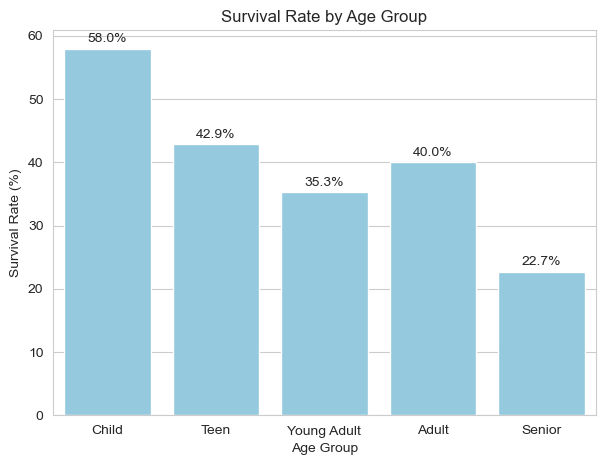

In [6]:
plt.figure(figsize=(7,5))

ax = sns.barplot(x=age_survival.index, y=age_survival.values, color='skyblue')

plt.title("Survival Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Survival Rate (%)")

for index, value in enumerate(age_survival.values):
    plt.text(index, value+1, f"{value:.1f}%", ha='center')

plt.show()

### Insight

Children show relatively higher survival rates compared to older passengers.
Senior passengers have the lowest survival probability.

## Survival Rate by Embarkation Port

Passengers boarded the Titanic from three ports:
- C (Cherbourg)
- Q (Queenstown)
- S (Southampton)

We'll analyze how survival differed by embarkation location.

### Answer

In [7]:
embark_survival = df.groupby('Embarked')['Survived'].mean()*100
embark_survival

Embarked
C    55.357143
Q    38.961039
S    33.900929
Name: Survived, dtype: float64

### Visualization

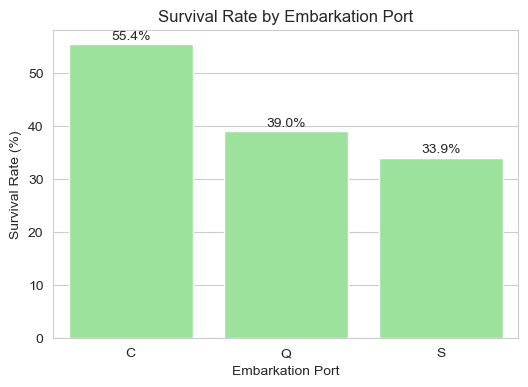

In [8]:
plt.figure(figsize=(6,4))

ax = sns.barplot(x=embark_survival.index, y=embark_survival.values, color='lightgreen')

plt.title("Survival Rate by Embarkation Port")
plt.xlabel("Embarkation Port")
plt.ylabel("Survival Rate (%)")

for index, value in enumerate(embark_survival.values):
    plt.text(index, value+1, f"{value:.1f}%", ha='center')

plt.show()

### Insight

Passengers who embarked from **Cherbourg (C)** had a higher survival rate compared to those from Southampton and Queenstown.

## Survival Rate by Family Size

Family size is calculated by combining:
- SibSp (siblings/spouses)
- Parch (parents/children)

This helps understand whether traveling alone or with family affected survival.

### Answer

In [9]:
df['Family_Size'] = df['SibSp'] + df['Parch'] + 1

family_survival = df.groupby('Family_Size')['Survived'].mean()*100
family_survival

Family_Size
1     30.353818
2     55.279503
3     57.843137
4     72.413793
5     20.000000
6     13.636364
7     33.333333
8      0.000000
11     0.000000
Name: Survived, dtype: float64

### Visualization 

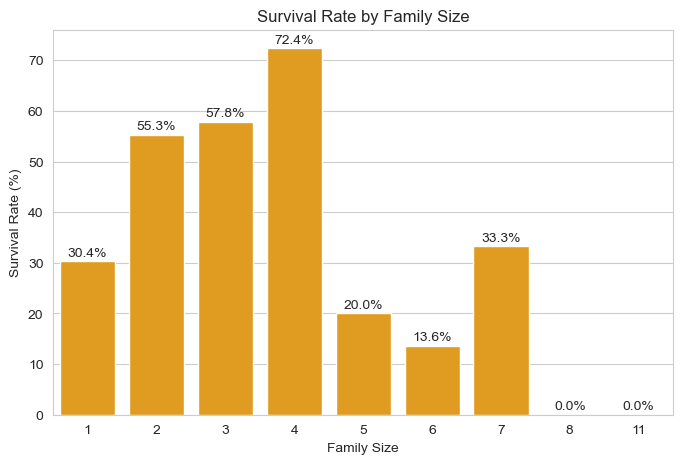

In [10]:
plt.figure(figsize=(8,5))

ax = sns.barplot(x=family_survival.index, y=family_survival.values, color='orange')

plt.title("Survival Rate by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Survival Rate (%)")

for index, value in enumerate(family_survival.values):
    plt.text(index, value+1, f"{value:.1f}%", ha='center')

plt.show()

### Insight

Passengers traveling with small families had better survival chances compared to those traveling alone or with very large families.

# 📈 VISUALIZATIONS

## 📊 Age Distribution of Passengers

A histogram is used to visualize the distribution of passenger ages in the Titanic dataset.

This helps us understand:
- The most common age range of passengers
- Whether the data is skewed
- The overall age distribution of people on board

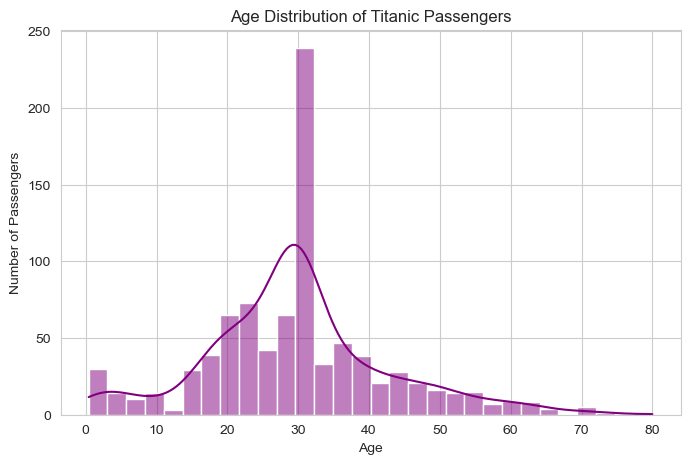

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=30, kde=True, color='purple')

plt.title("Age Distribution of Titanic Passengers")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

### Insight: Age Distribution of Passengers

The histogram shows that the majority of Titanic passengers were between **20 and 40 years old**, indicating that most travelers were young adults.

The distribution is slightly **right-skewed**, meaning there were fewer older passengers compared to younger ones.

Children and elderly passengers make up a smaller proportion of the dataset, suggesting that the passenger population was largely composed of working-age adults.

## 📊 Correlation Heatmap

A heatmap is used to visualize the correlation between numerical variables in the dataset.

Correlation values range from **-1 to 1**:
- **1** → Strong positive relationship
- **0** → No relationship
- **-1** → Strong negative relationship

This helps identify which variables are related to survival.

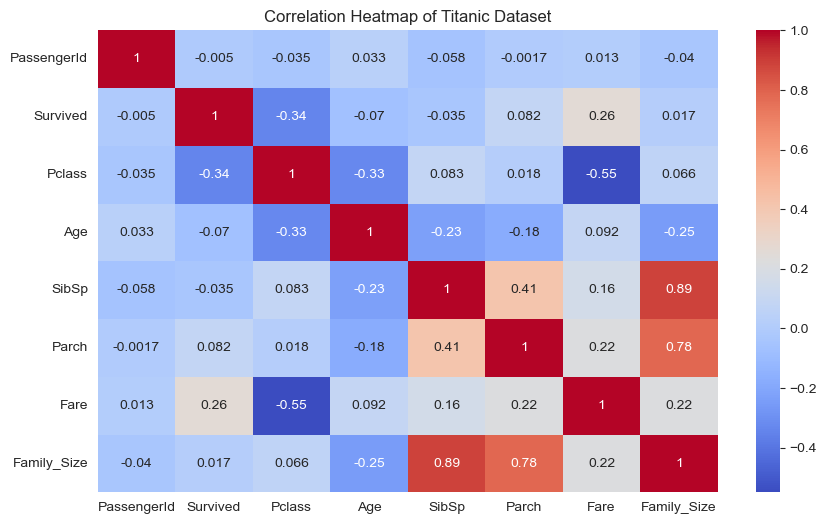

In [12]:
plt.figure(figsize=(10,6))

corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap of Titanic Dataset")

plt.show()

### Insight: Correlation Between Variables

The correlation heatmap highlights relationships between numerical variables in the dataset.

Key observations:

• **Pclass and Fare (-0.55)** show a strong negative correlation, indicating that passengers in higher classes generally paid higher fares.

• **Survived and Fare (0.26)** show a positive correlation, suggesting that passengers who paid higher fares had a higher chance of survival.

• **Survived and Pclass (-0.34)** indicates that passengers in higher classes had better survival probabilities.

• **SibSp and Family_Size (0.89)** and **Parch and Family_Size (0.78)** show strong correlations because family size is derived from these variables.

Overall, socio-economic factors such as passenger class and fare appear to influence survival chances.

## 📊 Survival Rate by Family Size

Family size is calculated by combining:
- **SibSp** (siblings/spouses aboard)
- **Parch** (parents/children aboard)

This analysis helps determine whether traveling alone or with family influenced survival chances.

In [13]:
# Create Family Size
df['Family_Size'] = df['SibSp'] + df['Parch'] + 1

# Calculate Survival Rate
family_survival = df.groupby('Family_Size')['Survived'].mean()*100
family_survival

Family_Size
1     30.353818
2     55.279503
3     57.843137
4     72.413793
5     20.000000
6     13.636364
7     33.333333
8      0.000000
11     0.000000
Name: Survived, dtype: float64

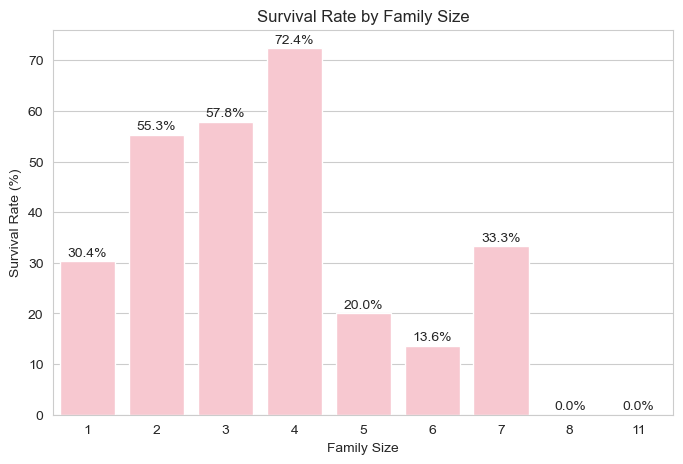

In [14]:
# Visualization
plt.figure(figsize=(8,5))

ax = sns.barplot(x=family_survival.index, y=family_survival.values, color='pink')

plt.title("Survival Rate by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Survival Rate (%)")

for index, value in enumerate(family_survival.values):
    plt.text(index, value+1, f"{value:.1f}%", ha='center')

plt.show()

### Insight: Survival Rate by Family Size

The bar chart shows that passengers traveling with **small families (2–4 members)** had the highest survival rates.

For example:
• Family size **4 had the highest survival rate (~72%)**
• Family sizes **2 and 3 also had relatively high survival rates (~55–58%)**

Passengers traveling **alone (family size = 1)** had a lower survival rate (~30%).

Very large families (**5 or more members**) experienced significantly lower survival rates, possibly due to difficulties staying together during evacuation.

This suggests that **moderate family support improved survival chances**, while traveling alone or in very large groups reduced survival probability.

#  📌 Summary
____

This analysis explored survival patterns in the Titanic dataset by examining passenger demographics, family relationships, and socio-economic factors.

## Key Takeaways

This analysis of the Titanic dataset revealed several important patterns related to passenger survival.

• The majority of passengers were **young adults between 20 and 40 years old**, indicating that the passenger demographic was largely composed of working-age individuals.

• **Passenger class and fare were strongly associated with survival chances**, suggesting that socio-economic status played a significant role during evacuation.

• **Family size influenced survival outcomes**, where passengers traveling with **small families (2–4 members)** experienced the highest survival rates.

• Passengers traveling **alone or with very large families** had lower survival probabilities, possibly due to lack of support or difficulty coordinating evacuation.

---

## Business Perspective

From a data analytics perspective, this project demonstrates how demographic and behavioral variables can influence outcomes during critical events.

Insights such as these can help organizations understand:

• The impact of **social hierarchy and access to resources**  
• How **group behavior (family travel)** affects safety outcomes  
• The importance of **data-driven decision making** in emergency planning

Such analyses are commonly used in fields like **risk analysis, transportation safety, and disaster management**.

---

## Limitations of the Analysis

While the dataset provides useful insights, there are some limitations:

• Some variables such as **Cabin location** had many missing values and could not be fully analyzed.

• The dataset does not capture **human behavior during evacuation**, which may also influence survival.

• The analysis is based on historical data and does not include external factors such as **crew instructions or lifeboat availability**.

---

## Future Work

This analysis can be extended further by applying machine learning techniques to predict survival.

Possible future improvements include:

• Building a **Logistic Regression model** to predict passenger survival  
• Applying **Decision Trees or Random Forest models** for classification  
• Performing **feature importance analysis** to identify the strongest predictors  
• Creating more advanced visualizations to uncover deeper patterns

---

## Conclusion

The results suggest that survival during the Titanic disaster was influenced by a combination of **social status, family structure, and passenger demographics**.

Passengers with better access to resources, higher-class cabins, and moderate family support had a greater probability of survival.

## Final Note

This project highlights the importance of **data cleaning, exploratory data analysis, and visualization** in understanding real-world datasets.

By transforming raw data into meaningful insights, data analysts can support informed decision-making and uncover hidden patterns within complex datasets.

In short, This analysis demonstrates how exploratory data analysis can reveal meaningful patterns and insights from historical datasets.